In [1]:
import vectorbt as vbt
import pandas as pd
import numpy as np
import datetime
import os
from dotenv import load_dotenv
from strategy import calculating_signal

# Решаем проблему связки европейского сервера с сервисами предоставления данных
load_dotenv()
proxy_login = os.getenv('PROXY_LOGIN')
proxy_password = os.getenv('PROXY_PASSWORD')
proxy_host = os.getenv('PROXY_HOST')
proxy_port = os.getenv('PROXY_PORT')
proxy_url = f"http://{proxy_login}:{proxy_password}@{proxy_host}:{proxy_port}"
os.environ['HTTP'] = proxy_url
os.environ['HTTPS'] = proxy_url

Start                         2026-05-08 12:00:00+00:00
End                           2026-07-07 12:00:00+00:00
Period                                 60 days 00:15:00
Start Value                                     10000.0
End Value                                  11655.027344
Total Return [%]                              16.550273
Benchmark Return [%]                         -20.755325
Max Gross Exposure [%]                        76.934096
Total Fees Paid                                     0.0
Max Drawdown [%]                               4.663835
Max Drawdown Duration                  18 days 20:30:00
Total Trades                                          4
Total Closed Trades                                   3
Total Open Trades                                     1
Open Trade PnL                               117.164844
Win Rate [%]                                      100.0
Best Trade [%]                                17.037243
Worst Trade [%]                                0

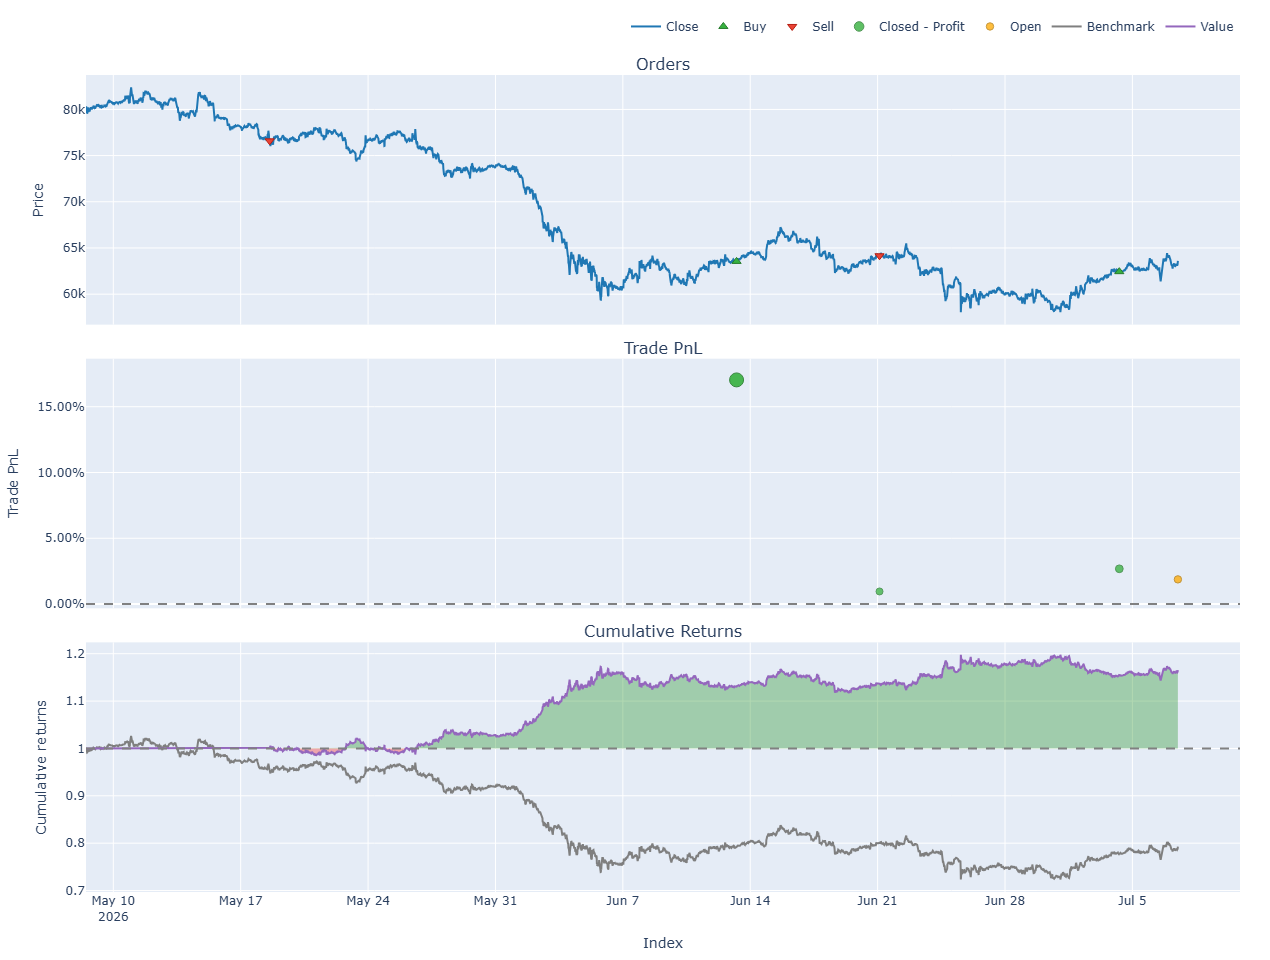

In [2]:
end_date = datetime.datetime.now()
start_date_15m = end_date - datetime.timedelta(days=60)

btc_price = vbt.YFData.download(
    'BTC-USD',
    missing_index = 'drop',
    start = start_date_15m,
    end = end_date,
    interval = "15m").get()

open_price = btc_price['Open']
high = btc_price['High']
low = btc_price['Low']
close = btc_price['Close']


EngulfingIndicator = vbt.IndicatorFactory(
    input_names = ['open_price', 'high', 'low', 'close'],
    param_names = ['reward_risk'],
    output_names = ['entry_flag', 'stop_loss','take_profit']
).from_apply_func(calculating_signal,
                  reward_risk = 1,
                  keep_pd=True
)

res = EngulfingIndicator.run(open_price, high, low, close,
    reward_risk=1)

pf = vbt.Portfolio.from_signals(
    close,
    entries = res.entry_flag==1,
    exits=None,
    short_entries = res.entry_flag==-1,
    short_exits=None,
    init_cash = 10000,
    size=0.1,
    sl_stop = res.stop_loss,
    tp_stop = res.take_profit,
)

print(pf.stats())
pf.plot().show()